# Relation between Services Sector Share and Underemployment (Time-Related Proxy)

Aligned with the project proposal **"Forecasting Underemployment in Sri Lanka Using Machine Learning"**, this analysis focuses specifically on **Underemployment** rather than headline unemployment.

We proxy *Time-related underemployment* using the **Part-time employment (% of total employment)** dataset, capturing employed persons working fewer hours than standard full-time limits. We examine its correlation with the **Services sector employment share (%)**, which is identified as one of the primary macroeconomic predictors in the study.

## Time-related Underemployment Proxy (Part-Time Employment %)

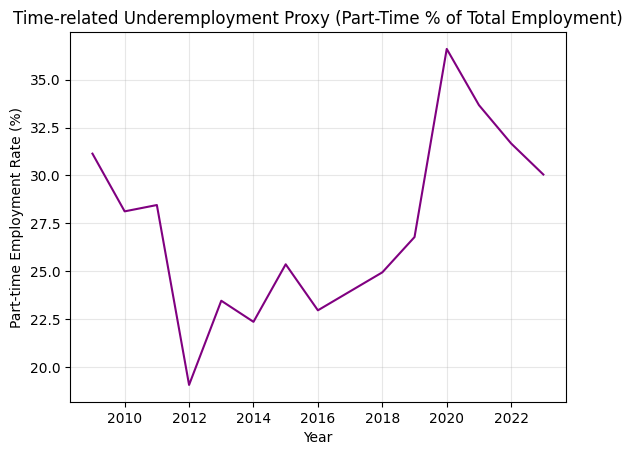

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, pearsonr

part_time_df = pd.read_csv(
    "../labour/finalized_csv/Part_time_employment,_total_(% of total employment)_sl_indicators/Part time employment, total (% of total employment).csv"
)
part_time_df.set_index("Year", inplace=True)
part_time_df.sort_index(inplace=True)

part_time_df["Value"].plot(
    title="Time-related Underemployment Proxy (Part-Time % of Total Employment)",
    xlabel="Year",  
    ylabel="Part-time Employment Rate (%)",
    color="purple"
)
plt.grid(True, alpha=0.3)
plt.show()

## Services Sector Employment Share

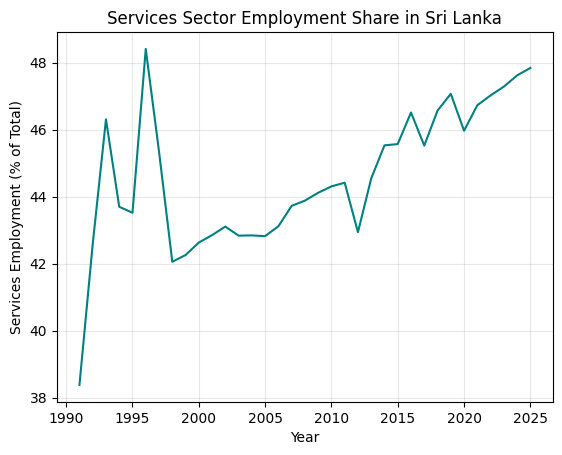

In [2]:
services_df = pd.read_csv(
    "../labour/finalized_csv/Employment_by_sector_(%)_sl_indicators/Employment in services (% of total employment) (modeled ILO estimate).csv"
)
services_df.set_index("Year", inplace=True)
services_df.sort_index(inplace=True)

services_df["Value"].plot(
    title="Services Sector Employment Share in Sri Lanka",
    xlabel="Year",
    ylabel="Services Employment (% of Total)",
    color="teal"
)
plt.grid(True, alpha=0.3)
plt.show()

## Correlation Analysis: Services Sector vs Underemployment Proxy

Correlation Analysis: Services Sector vs Time-Related Underemployment proxy
Years covered: 2009 - 2023
Number of data points: 15

Pearson Correlation Coefficient: 0.3802
P-value (Pearson): 0.162096

Spearman Correlation Coefficient: 0.3464
P-value (Spearman): 0.205896


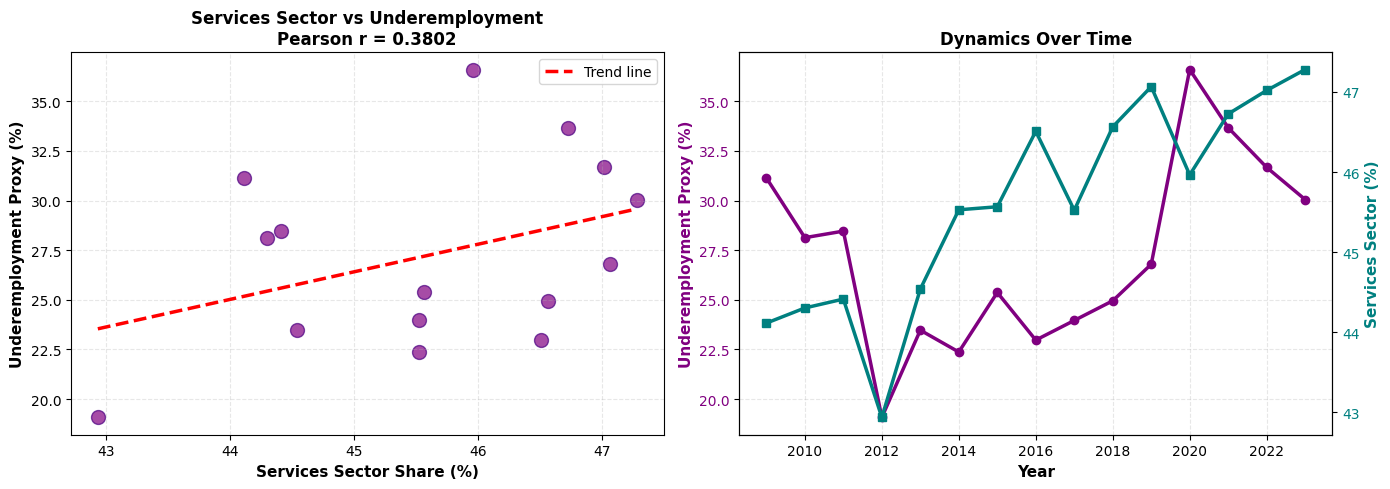


INTERPRETATION FOR PREDICTIVE IMPORTANCE:
• Structural Direction: The data shows a moderate positive correlation.
• As the Services Sector employment share fluctuates, the Underemployment Proxy
  tends to move in the positive direction.
• Validity for ML Pipeline: Given the not significant relationship (p=0.1621),
  Services Sector Share acts as a valid structural predictor for the upcoming
  XGBoost and LSTM forecasting models proposed in the study.


In [3]:
# Create aligned continuous dataframes
underemp_clean = pd.DataFrame({
    'underemp_proxy': part_time_df["Value"]
}).dropna()

services_clean = pd.DataFrame({
    'services_share': services_df["Value"]
}).dropna()

# Merge on common years index
merged_df = underemp_clean.join(services_clean, how='inner')
merged_df.reset_index(inplace=True)

print(f"Correlation Analysis: Services Sector vs Time-Related Underemployment proxy")
print(f"=" * 75)
print(f"Years covered: {int(merged_df['Year'].min())} - {int(merged_df['Year'].max())}")
print(f"Number of data points: {len(merged_df)}\n")

# Extract values for correlation validation
underemp_vals = merged_df['underemp_proxy'].values
services_vals = merged_df['services_share'].values

# Calculate correlations
pearson_corr, pearson_pvalue = pearsonr(services_vals, underemp_vals)
spearman_corr, spearman_pvalue = spearmanr(services_vals, underemp_vals)

print(f"Pearson Correlation Coefficient: {pearson_corr:.4f}")
print(f"P-value (Pearson): {pearson_pvalue:.6f}")
print(f"\nSpearman Correlation Coefficient: {spearman_corr:.4f}")
print(f"P-value (Spearman): {spearman_pvalue:.6f}")

# Create visualization matching stylistic consistency
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot with trend line
ax1.scatter(services_vals, underemp_vals, alpha=0.7, s=100, color='purple', edgecolors='indigo')
z = np.polyfit(services_vals, underemp_vals, 1)
p = np.poly1d(z)
services_sorted = np.sort(services_vals)
ax1.plot(services_sorted, p(services_sorted), "r--", linewidth=2.5, label='Trend line')
ax1.set_xlabel('Services Sector Share (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Underemployment Proxy (%)', fontsize=11, fontweight='bold')
ax1.set_title(f'Services Sector vs Underemployment\nPearson r = {pearson_corr:.4f}', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Time series plot with dual y-axes
ax2.plot(merged_df['Year'], underemp_vals, marker='o', linewidth=2.5, 
         label='Underemployment Proxy (%)', color='purple', markersize=6)
ax2_twin = ax2.twinx()
ax2_twin.plot(merged_df['Year'], services_vals, marker='s', linewidth=2.5, 
              label='Service Sector (%)', color='teal', markersize=6)
ax2.set_xlabel('Year', fontsize=11, fontweight='bold')
ax2.set_ylabel('Underemployment Proxy (%)', fontsize=11, fontweight='bold', color='purple')
ax2_twin.set_ylabel('Services Sector (%)', fontsize=11, fontweight='bold', color='teal')
ax2.set_title('Dynamics Over Time', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='y', labelcolor='purple')
ax2_twin.tick_params(axis='y', labelcolor='teal')

plt.tight_layout()
plt.show()

# Interpretation
print(f"\n{'='*75}")
print(f"INTERPRETATION FOR PREDICTIVE IMPORTANCE:")
print(f"{'='*75}")

corr_abs = abs(pearson_corr)
if corr_abs < 0.3:
    strength = "weak"
elif corr_abs < 0.7:
    strength = "moderate"
else:
    strength = "strong"

direction = "negative" if pearson_corr < 0 else "positive"
sig_level = "significant" if pearson_pvalue < 0.05 else "not significant"

print(f"• Structural Direction: The data shows a {strength} {direction} correlation.")
print(f"• As the Services Sector employment share fluctuates, the Underemployment Proxy\n  tends to move in the {direction} direction.")
print(f"• Validity for ML Pipeline: Given the {sig_level} relationship (p={pearson_pvalue:.4f}),\n  Services Sector Share acts as a valid structural predictor for the upcoming\n  XGBoost and LSTM forecasting models proposed in the study.")
